In [57]:
import torch, torchvision, numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [58]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0, 1)
])

In [59]:
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=8, shuffle=True)

In [60]:
testset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(testset, batch_size=8, shuffle=False)

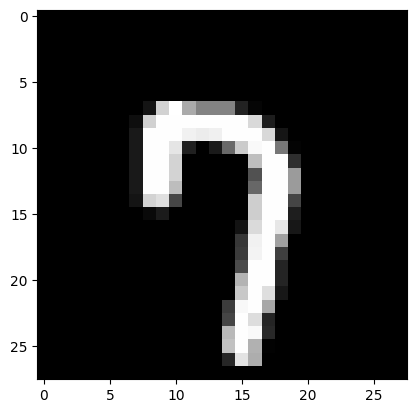

In [61]:
plt.imshow(next(iter(trainloader))[0][0][0], cmap='grey')

In [62]:
class CNN(nn.Module):
    def __init__(self, in_l, out_f):
        super().__init__()
        self.conv1 = nn.Conv2d(in_l, 6, kernel_size=4) # обучаемые параметры - это элементы свертки/ядра
        self.pool1 = nn.AvgPool2d(2, stride=2)

        self.conv2 = nn.Conv2d(6, 10, kernel_size=4, stride=2)
        self.pool2 = nn.AvgPool2d(2, stride=2)

        self.seq = nn.Sequential(
            nn.Linear(2*2*10, 20),
            nn.ReLU(),
            nn.Linear(20, out_f)
        )

    def forward(self, x):
        # print(x.shape)
        x = self.pool1(torch.relu(self.conv1(x)))
        # print(x.shape)
        x = self.pool2(torch.relu(self.conv2(x)))
        # print(x.shape)
        x = x.view(-1, 2*2*10)
        # print(x.shape)
        x = self.seq(x)
        return x

In [63]:
from tqdm import tqdm

 33%|███▎      | 1/3 [00:14<00:29, 14.65s/it]

0 :: 0.4809104563167784


 67%|██████▋   | 2/3 [00:29<00:14, 14.66s/it]

1 :: 0.21860215802067348


100%|██████████| 3/3 [00:43<00:00, 14.57s/it]

2 :: 0.17089301018758365


CNN(
  (conv1): Conv2d(1, 6, kernel_size=(4, 4), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 10, kernel_size=(4, 4), stride=(2, 2))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (seq): Sequential(
    (0): Linear(in_features=40, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
  )
)

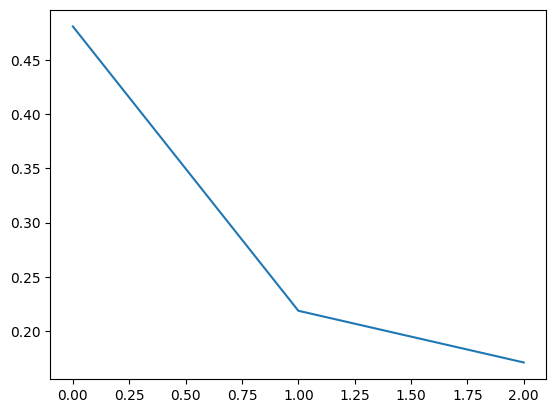

In [64]:
# net = CNN(1, 10).to(device='cuda')
net = CNN(1, 10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

def train(trainloader, model, criterion, optimizer, epoch=3):
    history_loss = []
    for e in tqdm(range(epoch)):
        e_loss = []
        for X, y in trainloader:
            y_pred = model(X)

            loss = criterion(y_pred, y)
            e_loss.append(loss.item())
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()
        print(e, '::', np.mean(e_loss))
        history_loss.append(np.mean(e_loss))
    plt.plot(history_loss)
    return model


train(trainloader, net, criterion, optimizer)

In [65]:
X, y = next(iter(test_loader))

y_pred = net(X)
print(y_pred.softmax(dim=1).argmax(dim=1),y, sep='\n')

tensor([7, 2, 1, 0, 4, 1, 4, 9])
tensor([7, 2, 1, 0, 4, 1, 4, 9])


In [66]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        y_pred = net(images)
        _, predicted = torch.max(y_pred, 1)
        
        c = (predicted.cpu().detach() == labels)
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

classes = list(range(10))
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of     0 : 97 %
Accuracy of     1 : 99 %
Accuracy of     2 : 95 %
Accuracy of     3 : 95 %
Accuracy of     4 : 97 %
Accuracy of     5 : 92 %
Accuracy of     6 : 98 %
Accuracy of     7 : 96 %
Accuracy of     8 : 94 %
Accuracy of     9 : 96 %
